# Customer Segmentation Using K-Means Clustering

## Project Overview

This project applies the K-Means clustering algorithm to customer
transaction data to identify distinct customer segments based on
purchasing behavior.

The analysis uses customer-level behavioral features derived from
the Online Retail dataset, including:

- Recency
- Frequency
- Monetary Value
- Total Quantity
- Average Order Value
- Unique Products

The final clustering solution uses **k = 3**, selected after
evaluating multiple candidate values of k using the Elbow Method,
Silhouette Score, cluster sizes, and business interpretability.

## Objectives

- Understand and clean the transaction dataset.
- Construct customer-level behavioral features.
- Explore customer purchasing behavior.
- Apply appropriate feature transformations and scaling.
- Determine a suitable number of customer segments.
- Train and validate a K-Means clustering model.
- Profile the resulting customer segments.
- Translate the clusters into actionable business insights.

## Final Model Summary

| Metric | Result |
|---|---:|
| Customers analyzed | 4,338 |
| Final number of clusters | 3 |
| Silhouette Score | 0.2609 |
| Algorithm | K-Means |
| Random State | 42 |

### Customer Segments

| Cluster | Segment | Customers | Share |
|---|---|---:|---:|
| 0 | At-Risk / Low-Value | 1,221 | 28.15% |
| 1 | High-Value Loyal | 1,188 | 27.39% |
| 2 | Regular / Growth | 1,929 | 44.47% |

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import warnings

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Customer-Level Features

The cleaned transaction data was transformed into customer-level
behavioral features during the feature engineering stage.

The resulting dataset contains one row per customer and summarizes
their purchasing behavior using Recency, Frequency, Monetary Value,
Total Quantity, Average Order Value, and Unique Products.

In [3]:
# ============================================================
# LOAD CUSTOMER-LEVEL FEATURES
# ============================================================

PROJECT_ROOT = Path.cwd()

# If the notebook is running from the notebooks directory,
# move one level up to the project root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CUSTOMER_FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_features.csv"
)

df = pd.read_csv(CUSTOMER_FEATURES_PATH)

print(f"Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully.
Shape: 4,338 rows × 7 columns


In [4]:
df.head()

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,UniqueProducts
0,12346,326,1,77183.60,74215,77183.600000,1
1,12347,2,7,4310.00,2458,615.714286,103
2,12348,75,4,1797.24,2341,449.310000,22
3,12349,19,1,1757.55,631,1757.550000,73
4,12350,310,1,334.40,197,334.400000,17


## 2. Data Validation

Before applying clustering, the customer-level dataset is validated
to ensure that:

- Required features are present.
- Missing values are not present.
- Each customer appears only once.
- CustomerID is treated only as an identifier.
- All clustering features contain valid non-negative values.

In [5]:
# ============================================================
# DATA VALIDATION
# ============================================================

FEATURE_COLUMNS = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "AverageOrderValue",
    "UniqueProducts",
]

# Check required columns
missing_columns = [
    column for column in FEATURE_COLUMNS + ["CustomerID"]
    if column not in df.columns
]

print("Required columns check:")
if missing_columns:
    print(f"Missing columns: {missing_columns}")
else:
    print("PASSED")

# Check missing values
print("\nMissing values:")
print(df[FEATURE_COLUMNS].isnull().sum())

# Check duplicate customers
print(f"\nDuplicate CustomerIDs: {df['CustomerID'].duplicated().sum():,}")

# Check negative values
print("\nNegative values:")
print((df[FEATURE_COLUMNS] < 0).sum())

# Final shape
print(f"\nFinal dataset shape: {df.shape[0]:,} customers × {df.shape[1]} columns")

Required columns check:
PASSED

Missing values:
Recency              0
Frequency            0
Monetary             0
TotalQuantity        0
AverageOrderValue    0
UniqueProducts       0
dtype: int64

Duplicate CustomerIDs: 0

Negative values:
Recency              0
Frequency            0
Monetary             0
TotalQuantity        0
AverageOrderValue    0
UniqueProducts       0
dtype: int64

Final dataset shape: 4,338 customers × 7 columns


In [6]:
# ============================================================
# FEATURE SUMMARY
# ============================================================

df[FEATURE_COLUMNS].describe().round(2)

,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,UniqueProducts
count,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69,1187.64,417.65,61.50
std,100.01,7.70,8985.23,5043.62,1796.51,85.37
min,1.00,1.00,3.75,1.00,3.45,1.00
25%,18.00,1.00,306.48,159.00,177.87,16.00
50%,51.00,2.00,668.57,378.00,291.94,35.00
75%,142.00,5.00,1660.60,989.75,428.28,77.00
max,374.00,209.00,280206.02,196915.00,84236.25,1787.00


## 3. Understanding Customer Features

The clustering model uses six customer-level behavioral features.

| Feature | Meaning | Business Interpretation |
|---|---|---|
| Recency | Days since the customer's most recent purchase | Lower values indicate more recent activity |
| Frequency | Number of unique orders made by the customer | Higher values indicate more frequent purchasing |
| Monetary | Total amount spent by the customer | Higher values indicate greater customer value |
| TotalQuantity | Total number of items purchased | Indicates overall purchase volume |
| AverageOrderValue | Average spending per order | Indicates spending level per transaction |
| UniqueProducts | Number of different products purchased | Indicates product variety |

In [7]:
# ============================================================
# FEATURE SUMMARY
# ============================================================

feature_summary = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Mean": [df[feature].mean() for feature in FEATURE_COLUMNS],
    "Median": [df[feature].median() for feature in FEATURE_COLUMNS],
    "Minimum": [df[feature].min() for feature in FEATURE_COLUMNS],
    "Maximum": [df[feature].max() for feature in FEATURE_COLUMNS],
})

feature_summary.round(2)

,Feature,Mean,Median,Minimum,Maximum
0,Recency,92.54,51.00,1.00,374.00
1,Frequency,4.27,2.00,1.00,209.00
2,Monetary,2048.69,668.57,3.75,280206.02
3,TotalQuantity,1187.64,378.00,1.00,196915.00
4,AverageOrderValue,417.65,291.94,3.45,84236.25
5,UniqueProducts,61.50,35.00,1.00,1787.00


## 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the
distribution and relationships of customer behavioral features
before applying clustering.

Understanding these distributions is important because K-Means
is distance-based and can be strongly affected by extreme values.

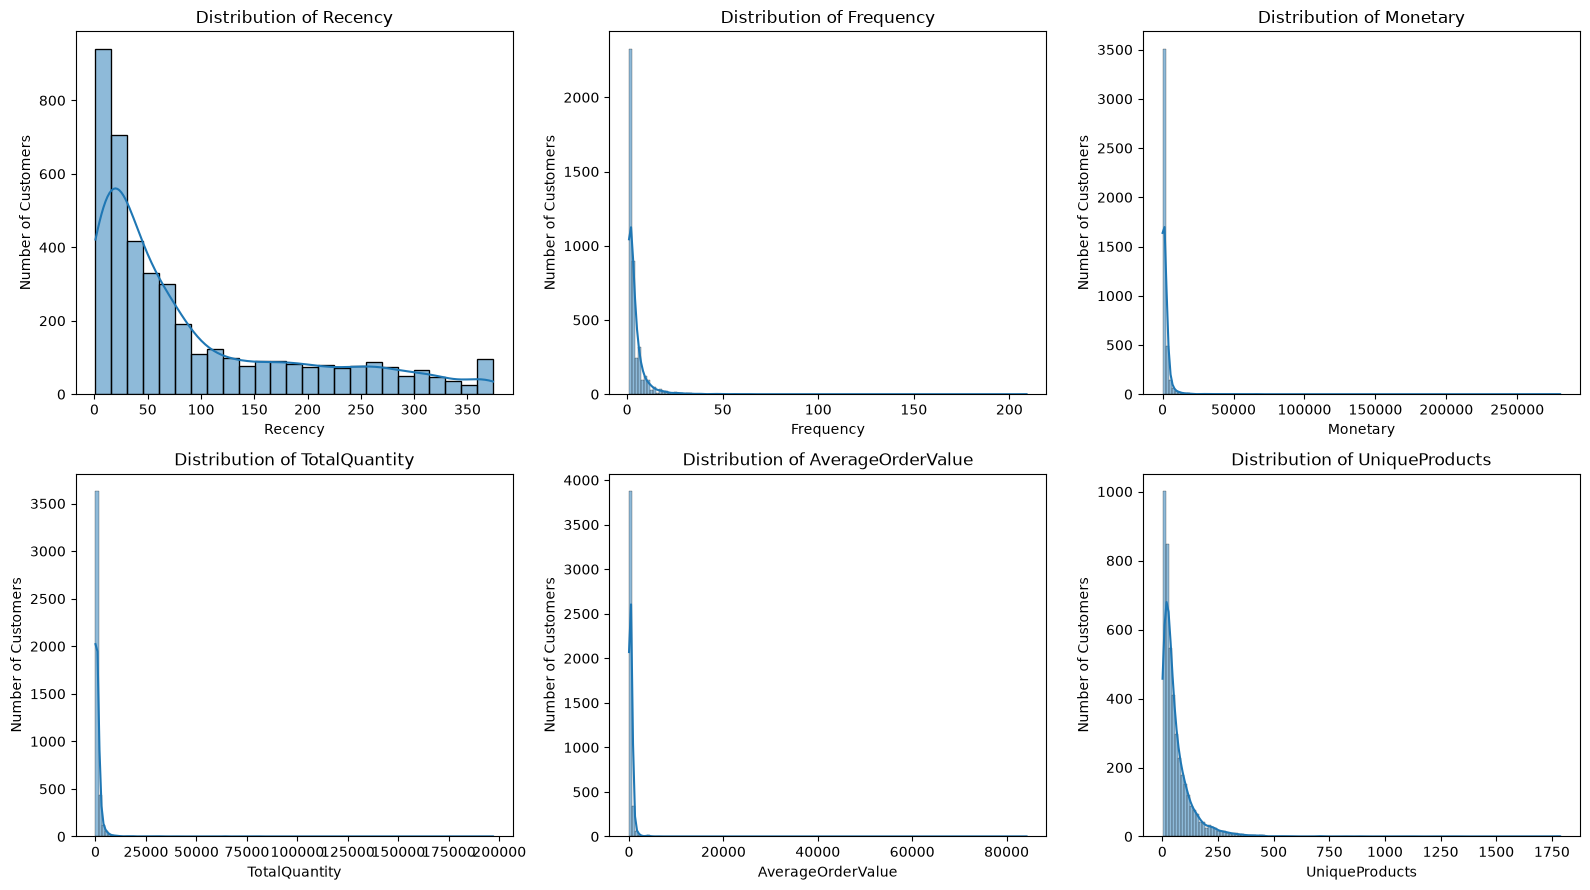

In [8]:
# ============================================================
# FEATURE DISTRIBUTIONS
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, feature in zip(axes.flatten(), FEATURE_COLUMNS):
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Feature Correlation

The correlation matrix is used to understand relationships between
customer behavioral features.

Strong correlations may indicate that some purchasing behaviors
tend to occur together, while weaker correlations indicate more
independent aspects of customer behavior.

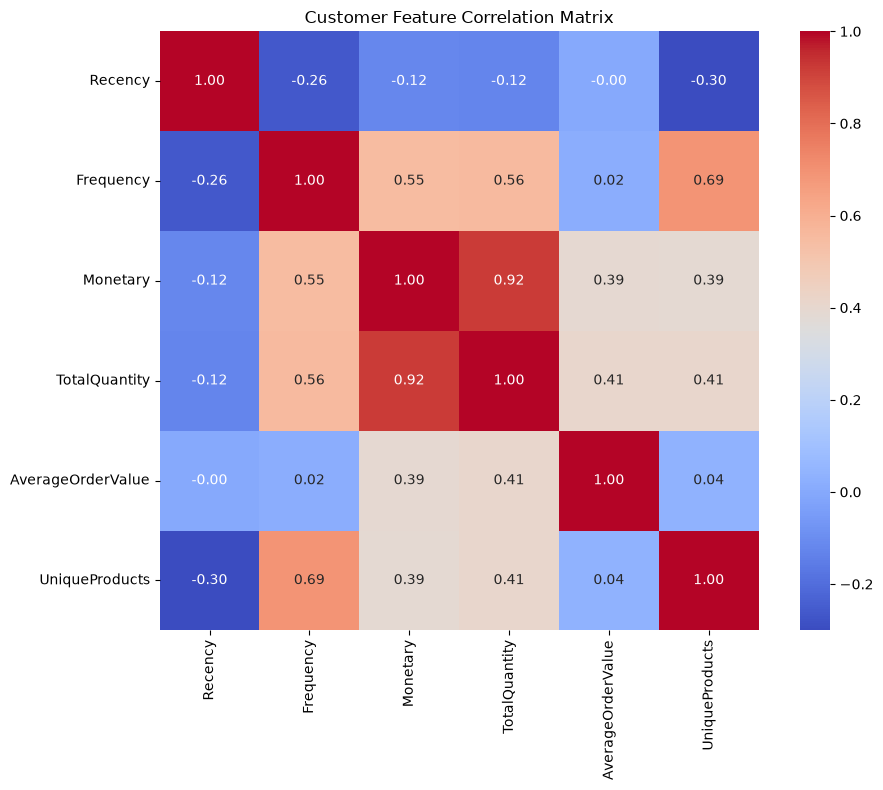

In [9]:
# ============================================================
# CORRELATION MATRIX
# ============================================================

correlation_matrix = df[FEATURE_COLUMNS].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Customer Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## 5. Feature Transformation

The customer features show substantial positive skewness and contain
large differences in magnitude.

A logarithmic transformation is therefore applied using `log1p`.

The transformation reduces the influence of extreme values while
preserving the relative ordering of customers.

`log1p(x)` is used instead of `log(x)` because it is well-defined
for zero-valued features.

In [10]:
# ============================================================
# APPLY LOG1P TRANSFORMATION
# ============================================================

log_df = df.copy()

log_df[FEATURE_COLUMNS] = np.log1p(
    log_df[FEATURE_COLUMNS]
)

print("Log1p transformation applied successfully.")

log_df[FEATURE_COLUMNS].describe().round(2)

Log1p transformation applied successfully.


,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,UniqueProducts
count,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00
mean,3.83,1.35,6.59,5.98,5.65,3.55
std,1.34,0.68,1.26,1.37,0.75,1.13
min,0.69,0.69,1.56,0.69,1.49,0.69
25%,2.94,0.69,5.73,5.08,5.19,2.83
50%,3.95,1.10,6.51,5.94,5.68,3.58
75%,4.96,1.79,7.42,6.90,6.06,4.36
max,5.93,5.35,12.54,12.19,11.34,7.49


### Feature Standardization

After logarithmic transformation, the features are standardized using
`StandardScaler`.

Standardization places the features on a comparable scale by
transforming them to approximately:

- Mean = 0
- Standard deviation = 1

This is important because K-Means uses distance calculations when
forming clusters.

In [11]:
# ============================================================
# STANDARDIZE FEATURES
# ============================================================

scaler = StandardScaler()

scaled_values = scaler.fit_transform(
    log_df[FEATURE_COLUMNS]
)

scaled_df = pd.DataFrame(
    scaled_values,
    columns=FEATURE_COLUMNS,
    index=log_df.index
)

print("Standardization completed successfully.")

scaled_df.describe().round(2)

Standardization completed successfully.


,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,UniqueProducts
count,4338.00,4338.00,4338.00,4338.00,4338.00,4338.00
mean,-0.00,-0.00,-0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.34,-0.96,-4.00,-3.86,-5.57,-2.53
25%,-0.66,-0.96,-0.68,-0.66,-0.62,-0.63
50%,0.09,-0.36,-0.07,-0.03,0.05,0.03
75%,0.84,0.65,0.66,0.67,0.56,0.71
max,1.56,5.86,4.73,4.53,7.64,3.48


## 6. Selecting the Number of Clusters

Multiple candidate values of `k` are evaluated using the Elbow Method
and Silhouette Score.

The analysis considers values of `k` from 2 through 10.

The final value of `k` will be selected using both quantitative
evaluation and business interpretability.

In [12]:
# ============================================================
# K SELECTION: ELBOW METHOD + SILHOUETTE SCORE
# ============================================================

X = scaled_df[FEATURE_COLUMNS]

k_values = range(2, 11)

inertia_values = []
silhouette_values = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    inertia_values.append(model.inertia_)
    silhouette_values.append(
        silhouette_score(X, labels)
    )

k_results = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertia_values,
    "Silhouette Score": silhouette_values
})

k_results.round(4)

,k,Inertia,Silhouette Score
0,2,15009.1081,0.3560
1,3,11948.0067,0.2609
2,4,10456.0657,0.2261
3,5,9295.8044,0.2270
4,6,8471.9134,0.2124
5,7,7925.2223,0.2064
6,8,7441.9550,0.2057
7,9,7038.8987,0.2037
8,10,6682.2051,0.1954


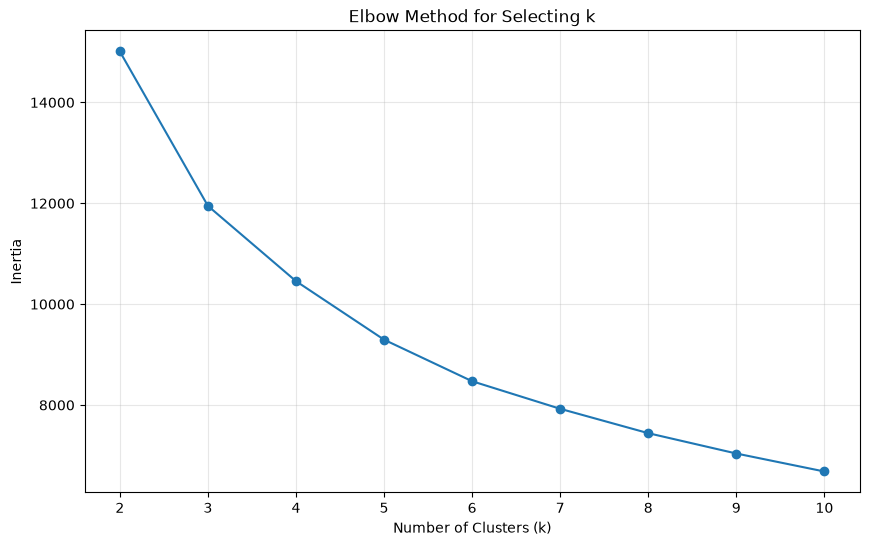

In [13]:
# ============================================================
# ELBOW CURVE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    k_results["k"],
    k_results["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Selecting k")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)

plt.show()

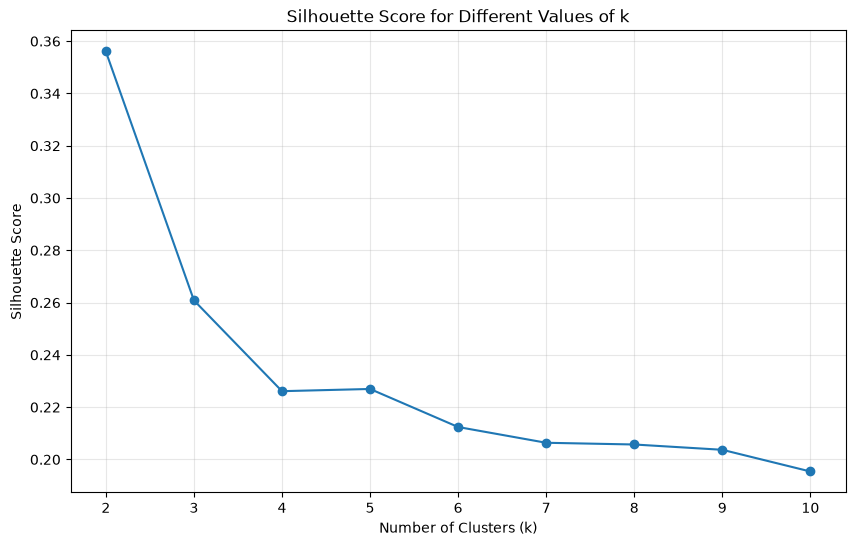

In [14]:
# ============================================================
# SILHOUETTE SCORE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    k_results["k"],
    k_results["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Values of k")
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)

plt.show()

### K Selection Decision

The Silhouette Score is highest for `k = 2` with a score of `0.3560`.

However, `k = 3` was selected as the final clustering solution
because it provides a more useful business segmentation while
maintaining a reasonable level of cluster separation.

The three-cluster solution distinguishes:

1. At-Risk / Low-Value customers
2. High-Value Loyal customers
3. Regular / Growth customers

Higher values of `k` produce additional clusters but do not provide
a sufficient improvement in clustering quality to justify the added
complexity.

Therefore, the final model uses **k = 3**.

## 7. Final K-Means Model

Based on the k-selection analysis, the final clustering model uses
three clusters.

K-Means is trained on the log-transformed and standardized customer
behavioral features.

The `CustomerID` is retained separately as an identifier and is not
used as a clustering feature.

In [15]:
# ============================================================
# TRAIN FINAL K-MEANS MODEL
# ============================================================

FINAL_K = 3

final_model = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=10
)

cluster_labels = final_model.fit_predict(X)

# Add cluster labels to customer data
clustered_df = df.copy()
clustered_df["Cluster"] = cluster_labels

print("Final K-Means model trained successfully.")
print(f"Number of clusters: {FINAL_K}")

Final K-Means model trained successfully.
Number of clusters: 3


In [16]:
# ============================================================
# CLUSTER SIZES
# ============================================================

cluster_counts = (
    clustered_df["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_percentages = (
    cluster_counts / len(clustered_df) * 100
)

cluster_summary = pd.DataFrame({
    "Customers": cluster_counts,
    "Percentage": cluster_percentages.round(2)
})

cluster_summary

,Customers,Percentage
Cluster,,
0,1221,28.15
1,1188,27.39
2,1929,44.47


### Final Model Evaluation

The Silhouette Score is calculated for the final three-cluster
solution to measure how well-separated and internally cohesive
the resulting clusters are.

In [17]:
# ============================================================
# FINAL SILHOUETTE SCORE
# ============================================================

final_silhouette = silhouette_score(
    X,
    clustered_df["Cluster"]
)

print(f"Final Silhouette Score: {final_silhouette:.4f}")

Final Silhouette Score: 0.2609


In [18]:
# ============================================================
# CLUSTER CENTERS
# ============================================================

cluster_centers = pd.DataFrame(
    final_model.cluster_centers_,
    columns=FEATURE_COLUMNS
)

cluster_centers.index.name = "Cluster"

cluster_centers.round(3)

,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,UniqueProducts
Cluster,,,,,,
0,0.649,-0.751,-1.098,-1.096,-0.891,-1.024
1,-0.869,1.237,1.188,1.134,0.526,0.980
2,0.125,-0.288,-0.039,-0.006,0.239,0.043


### Comparing k = 2 and k = 3

Although `k = 2` achieves a higher Silhouette Score, the three-cluster
solution provides greater business interpretability.

The comparison below shows the resulting cluster sizes for both
solutions.

In [19]:
# ============================================================
# COMPARE k=2 AND k=3
# ============================================================

comparison_models = {}

for k in [2, 3]:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    comparison_models[k] = {
        "labels": labels,
        "silhouette": silhouette_score(X, labels)
    }

comparison_rows = []

for k, result in comparison_models.items():
    labels = result["labels"]
    counts = pd.Series(labels).value_counts().sort_index()

    for cluster, count in counts.items():
        comparison_rows.append({
            "k": k,
            "Cluster": cluster,
            "Customers": count,
            "Percentage": round(count / len(X) * 100, 2),
            "Silhouette Score": round(result["silhouette"], 4)
        })

k_comparison = pd.DataFrame(comparison_rows)

k_comparison

,k,Cluster,Customers,Percentage,Silhouette Score
0,2,0,2404,55.42,0.3560
1,2,1,1934,44.58,0.3560
2,3,0,1221,28.15,0.2609
3,3,1,1188,27.39,0.2609
4,3,2,1929,44.47,0.2609


## 8. Customer Cluster Profiling

To interpret the resulting clusters, the original customer-level
features are grouped by cluster.

The mean values of Recency, Frequency, Monetary Value, Total Quantity,
Average Order Value, and Unique Products are compared across clusters.

These original-scale values make the resulting segments easier to
interpret from a business perspective.

In [21]:
# ============================================================
# CLUSTER PROFILE — ORIGINAL SCALE
# ============================================================

PROFILE_COLUMNS = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "AverageOrderValue",
    "UniqueProducts",
]

cluster_profile = (
    clustered_df
    .groupby("Cluster")[PROFILE_COLUMNS]
    .mean()
    .round(2)
)

cluster_profile

,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,UniqueProducts
Cluster,,,,,,
0,163.83,1.39,215.00,117.24,170.62,13.71
1,25.13,10.28,5918.11,3423.36,679.84,137.67
2,88.92,2.40,826.33,488.29,412.53,44.84


In [22]:
# ============================================================
# ADD CUSTOMER COUNTS AND PERCENTAGES
# ============================================================

cluster_profile["CustomerCount"] = (
    clustered_df["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_profile["CustomerPercentage"] = (
    cluster_profile["CustomerCount"]
    / len(clustered_df)
    * 100
).round(2)

cluster_profile

,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,UniqueProducts,CustomerCount,CustomerPercentage
Cluster,,,,,,,,
0,163.83,1.39,215.00,117.24,170.62,13.71,1221,28.15
1,25.13,10.28,5918.11,3423.36,679.84,137.67,1188,27.39
2,88.92,2.40,826.33,488.29,412.53,44.84,1929,44.47


In [23]:
# ============================================================
# ASSIGN BUSINESS SEGMENT NAMES
# ============================================================

segment_names = {
    0: "At-Risk / Low-Value",
    1: "High-Value Loyal",
    2: "Regular / Growth",
}

clustered_df["Segment"] = (
    clustered_df["Cluster"]
    .map(segment_names)
)

clustered_df[
    ["CustomerID", "Cluster", "Segment"]
].head(10)

,CustomerID,Cluster,Segment
0,12346,1,High-Value Loyal
1,12347,1,High-Value Loyal
2,12348,2,Regular / Growth
3,12349,2,Regular / Growth
4,12350,0,At-Risk / Low-Value
5,12352,1,High-Value Loyal
6,12353,0,At-Risk / Low-Value
7,12354,2,Regular / Growth
8,12355,2,Regular / Growth
9,12356,1,High-Value Loyal


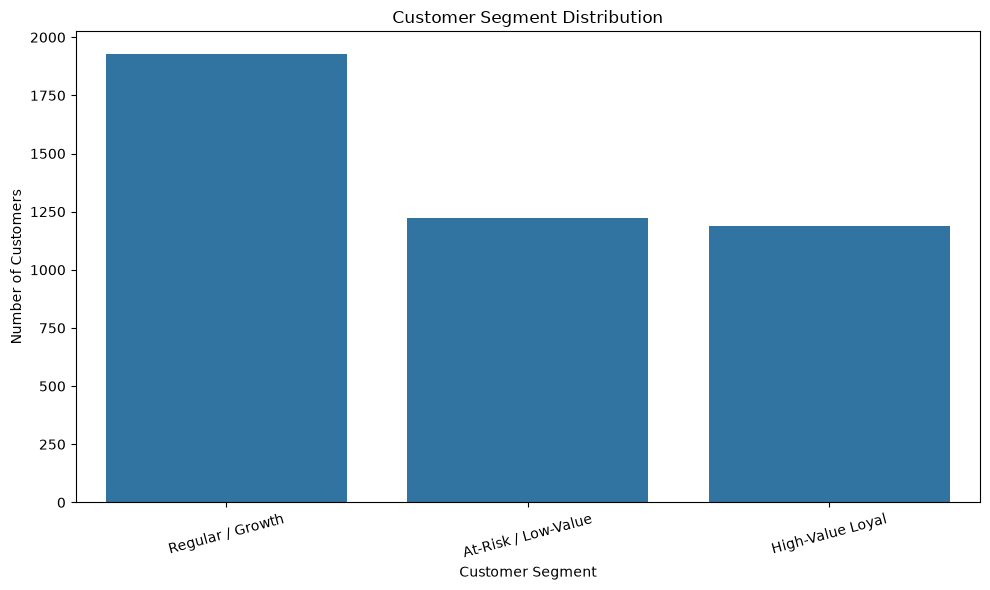

In [24]:
# ============================================================
# CLUSTER DISTRIBUTION
# ============================================================

segment_counts = (
    clustered_df["Segment"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## 9. Cluster Distribution

The distribution of customers across the three segments is visualized
to understand the relative size of each customer group.

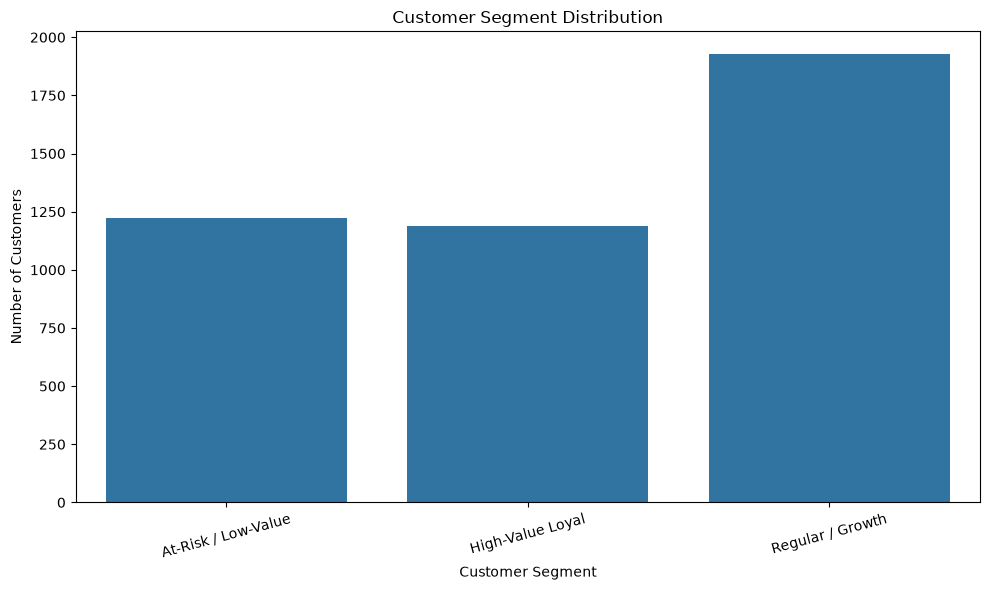

In [25]:
# ============================================================
# CLUSTER DISTRIBUTION
# ============================================================

segment_order = [
    "At-Risk / Low-Value",
    "High-Value Loyal",
    "Regular / Growth"
]

segment_counts = (
    clustered_df["Segment"]
    .value_counts()
    .reindex(segment_order)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## 10. Two-Dimensional Cluster Visualization

The K-Means model operates on six customer behavioral features, which
cannot be directly visualized in a two-dimensional plot.

Principal Component Analysis (PCA) is therefore used to project the
six-dimensional feature space into two dimensions for visualization.

PCA is used only to visualize the final clusters; the K-Means model
itself is trained using all six standardized features.

In [26]:
# ============================================================
# PCA FOR 2D CLUSTER VISUALIZATION
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clustered_df["Cluster"].values
pca_df["Segment"] = clustered_df["Segment"].values

print(
    f"Variance explained by PC1: "
    f"{pca.explained_variance_ratio_[0]:.2%}"
)

print(
    f"Variance explained by PC2: "
    f"{pca.explained_variance_ratio_[1]:.2%}"
)

print(
    f"Total variance explained: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

Variance explained by PC1: 65.76%
Variance explained by PC2: 17.39%
Total variance explained: 83.15%


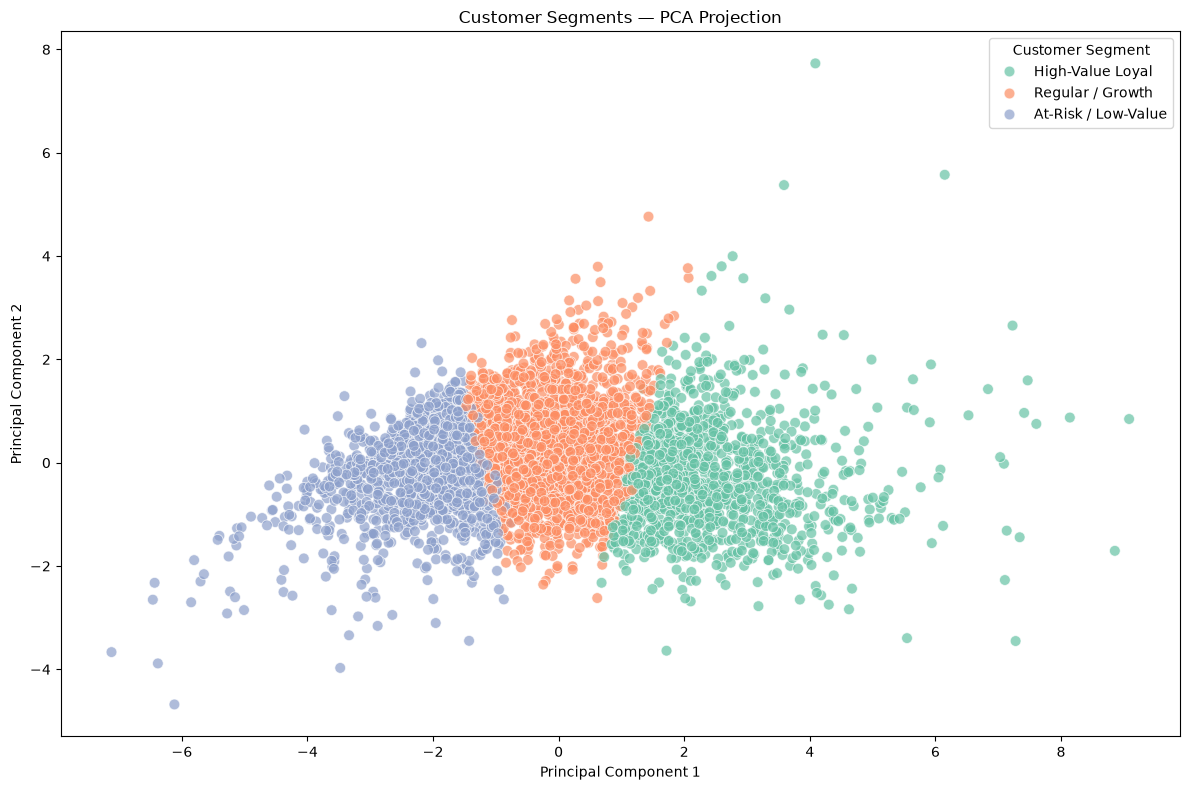

In [27]:
# ============================================================
# CUSTOMER CLUSTER VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Segment",
    palette="Set2",
    alpha=0.7,
    s=60
)

plt.title("Customer Segments — PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Customer Segment")

plt.tight_layout()

pca_plot_path = PROJECT_ROOT / "outputs" / "plots" / "customer_clusters_pca.png"
plt.savefig(pca_plot_path, dpi=300, bbox_inches="tight")
print(f"Saved: {pca_plot_path}")

plt.show()

### Cluster Behavioral Profile

The following heatmap compares the average behavioral characteristics
of the three customer segments.

The values are standardized within the visualization to make the
different features easier to compare.

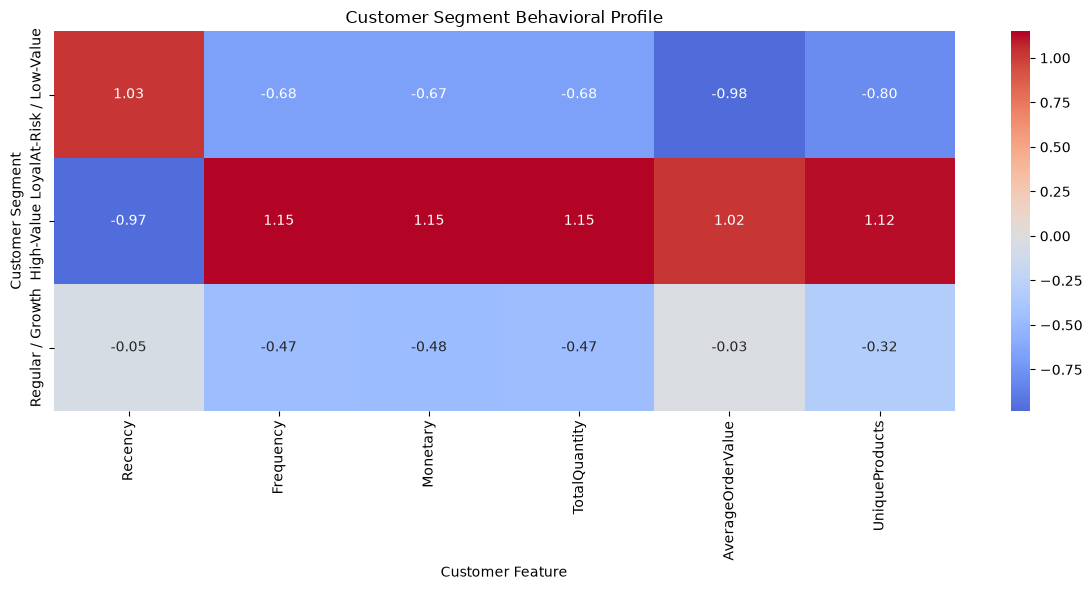

In [28]:
# ============================================================
# CLUSTER PROFILE HEATMAP
# ============================================================

heatmap_data = cluster_profile[
    PROFILE_COLUMNS
].copy()

heatmap_data.index = [
    segment_names[index]
    for index in heatmap_data.index
]

heatmap_scaled = (
    heatmap_data - heatmap_data.mean()
) / heatmap_data.std()

plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Customer Segment Behavioral Profile")
plt.xlabel("Customer Feature")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

## 11. Final Customer Segmentation Results

The final clustering results are saved as a customer-level dataset.

Each customer is associated with:

- Their original behavioral features
- The assigned K-Means cluster
- The corresponding business segment

In [29]:
# ============================================================
# FINAL CUSTOMER SEGMENTATION TABLE
# ============================================================

final_customer_segments = clustered_df[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "TotalQuantity",
        "AverageOrderValue",
        "UniqueProducts",
        "Cluster",
        "Segment",
    ]
].copy()

final_customer_segments.head(10)

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,UniqueProducts,Cluster,Segment
0,12346,326,1,77183.60,74215,77183.600000,1,1,High-Value Loyal
1,12347,2,7,4310.00,2458,615.714286,103,1,High-Value Loyal
2,12348,75,4,1797.24,2341,449.310000,22,2,Regular / Growth
3,12349,19,1,1757.55,631,1757.550000,73,2,Regular / Growth
4,12350,310,1,334.40,197,334.400000,17,0,At-Risk / Low-Value
5,12352,36,8,2506.04,536,313.255000,59,1,High-Value Loyal
6,12353,204,1,89.00,20,89.000000,4,0,At-Risk / Low-Value
7,12354,232,1,1079.40,530,1079.400000,58,2,Regular / Growth
8,12355,214,1,459.40,240,459.400000,13,2,Regular / Growth
9,12356,23,3,2811.43,1591,937.143333,53,1,High-Value Loyal


In [30]:
# ============================================================
# SAVE CUSTOMER SEGMENTATION RESULTS
# ============================================================

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

CUSTOMER_SEGMENTS_PATH = (
    OUTPUTS_DIR / "customer_segments.csv"
)

final_customer_segments.to_csv(
    CUSTOMER_SEGMENTS_PATH,
    index=False
)

print(f"Customer segmentation saved to:")
print(CUSTOMER_SEGMENTS_PATH)

Customer segmentation saved to:
d:\TASKS\kmeans-customer-segmentation\outputs\customer_segments.csv


## 12. Final Cluster Profiles

The final cluster profile summarizes the behavioral characteristics
of each customer segment using the original feature values.

These profiles are used to translate the mathematical clusters into
business-oriented customer segments.

In [31]:
# ============================================================
# FINAL CLUSTER PROFILE
# ============================================================

final_cluster_profile = (
    clustered_df
    .groupby(["Cluster", "Segment"])[PROFILE_COLUMNS]
    .mean()
    .round(2)
)

final_cluster_profile

,,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,UniqueProducts
Cluster,Segment,,,,,,
0,At-Risk / Low-Value,163.83,1.39,215.00,117.24,170.62,13.71
1,High-Value Loyal,25.13,10.28,5918.11,3423.36,679.84,137.67
2,Regular / Growth,88.92,2.40,826.33,488.29,412.53,44.84


In [32]:
# ============================================================
# ADD CLUSTER SIZES
# ============================================================

cluster_sizes = (
    clustered_df
    .groupby(["Cluster", "Segment"])
    .size()
    .reset_index(name="CustomerCount")
)

cluster_sizes["CustomerPercentage"] = (
    cluster_sizes["CustomerCount"]
    / len(clustered_df)
    * 100
).round(2)

cluster_sizes

,Cluster,Segment,CustomerCount,CustomerPercentage
0,0,At-Risk / Low-Value,1221,28.15
1,1,High-Value Loyal,1188,27.39
2,2,Regular / Growth,1929,44.47


## 13. Final Model Summary

The final K-Means model successfully segmented 4,338 customers into
three behaviorally distinct groups.

The segmentation provides a practical framework for understanding
customer engagement and value.

### Final Segments

- **At-Risk / Low-Value:** Customers with low purchase frequency,
  low monetary value, limited product variety, and relatively long
  periods since their last purchase.

- **High-Value Loyal:** Recently active customers with high purchase
  frequency, high monetary value, high purchase volume, and broad
  product engagement.

- **Regular / Growth:** Customers with moderate engagement and value
  who represent an opportunity for targeted growth and increased
  repeat purchasing.

The final model achieved a Silhouette Score of approximately `0.2609`.

# ============================================================
# FINAL PROJECT SUMMARY
# ============================================================

print("=" * 60)
print("FINAL K-MEANS CUSTOMER SEGMENTATION")
print("=" * 60)

print(f"Customers analyzed : {len(clustered_df):,}")
print(f"Number of clusters : {FINAL_K}")
print(f"Silhouette Score   : {final_silhouette:.4f}")

print("\nCustomer Segments:")
print(cluster_sizes.to_string(index=False))

print("\nFinal clustering analysis completed successfully.")